In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Consistent aesthetics for seaborn/matplotlib
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 6)

print("Improting done")

Improting done


In [2]:
df = pd.read_csv('../data/raw/ai4i2020.csv')


print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head(5)

Shape: (10000, 14)
Columns: ['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
# ── CELL 3: Sanity checks ───────────────────────────

# 3a. Data types
print("=== DATA TYPES ===")
print(df.dtypes)

# 3b. Missing values — expect zero for this dataset
print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

# 3c. Duplicate rows
print(f"\nDuplicate rows: {df.duplicated().sum()}")

# 3d. Summary statistics
df.describe().round(2)

# ── CELL 3e: Class balance check ────────────────────
failure_rate = df['Machine failure'].mean() * 100
print(f"Overall failure rate: {failure_rate:.1f}%")
print(df['Machine failure'].value_counts())

# Failure breakdown by type
failure_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
print("\n=== FAILURES BY TYPE ===")
print(df[failure_cols].sum().sort_values(ascending=False))

# ── CELL 3f: Product quality distribution ───────────
print("Product quality distribution:")
print(df['Type'].value_counts())
print("\nFailure rate by product type:")
print(df.groupby('Type')['Machine failure'].mean().mul(100).round(1))

=== DATA TYPES ===
UDI                          int64
Product ID                     str
Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

=== MISSING VALUES ===
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

Duplicate rows: 0
Overall failure

In [4]:
# ── CELL 4: Data Cleaning ───────────────────────────

# 4a. Copy raw — never modify df directly
df_clean = df.copy()

# 4b. Rename columns to be Python-friendly
df_clean.columns = [
    'udi', 'product_id', 'type',
    'air_temp_k', 'process_temp_k', 'rpm',
    'torque_nm', 'tool_wear_min', 'machine_failure',
    'twf', 'hdf', 'pwf', 'osf', 'rnf'
]

# 4c. Drop identifier columns (not useful for analysis)
df_clean = df_clean.drop(columns=['udi', 'product_id'])

# 4d. Encode product type: L=0, M=1, H=2
type_map = {'L': 0, 'M': 1, 'H': 2}
df_clean['type_encoded'] = df_clean['type'].map(type_map)

# 4e. Drop RNF column — it is random noise, not a real failure mode
# (documented in the original paper: RNF = random noise failures)
df_clean = df_clean.drop(columns=['rnf'])

print(f"Clean dataset shape: {df_clean.shape}")
print("Columns kept:", list(df_clean.columns))
df_clean.head(3)

Clean dataset shape: (10000, 12)
Columns kept: ['type', 'air_temp_k', 'process_temp_k', 'rpm', 'torque_nm', 'tool_wear_min', 'machine_failure', 'twf', 'hdf', 'pwf', 'osf', 'type_encoded']


,type,air_temp_k,process_temp_k,rpm,torque_nm,tool_wear_min,machine_failure,twf,hdf,pwf,osf,type_encoded
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,1
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0


In [5]:
df_clean.to_csv('../data/processed/manufacturing_clean.csv', index=False)
print("Saved to data/processed/manufacturing_clean.csv")

Saved to data/processed/manufacturing_clean.csv


In [6]:
# ── CELL 6: Feature Engineering ─────────────────────

# 6a. Thermal differential (process heat minus ambient)
df_clean['temp_diff'] = df_clean['process_temp_k'] - df_clean['air_temp_k']

# 6b. Mechanical power (convert rpm to rad/s first)
df_clean['power_w'] = df_clean['torque_nm'] * (df_clean['rpm'] * 2 * np.pi / 60)

# 6c. Tool wear bins (5 equal-width stages)
df_clean['wear_bin'] = pd.cut(
    df_clean['tool_wear_min'],
    bins=[0, 50, 100, 150, 200, 260],
    labels=['Fresh', 'Light', 'Moderate', 'Heavy', 'Critical']
)

# 6d. Overstrain proxy (high wear + high torque = compounded stress)
df_clean['overstrain'] = df_clean['tool_wear_min'] * df_clean['torque_nm']

# Verify new columns
print("New features added:")
print(df_clean[['temp_diff', 'power_w', 'wear_bin', 'overstrain']].describe().round(1))

# 6e. Re-save the enriched dataset
df_clean.to_csv('../data/processed/manufacturing_features.csv', index=False)
print("✓ Feature-engineered dataset saved")

New features added:
       temp_diff  power_w  overstrain
count    10000.0  10000.0     10000.0
mean        10.0   6279.7      4314.7
std          1.0   1067.4      2826.6
min          7.6   1148.4         0.0
25%          9.3   5561.2      1963.6
50%          9.8   6271.0      4013.0
75%         11.0   7003.0      6279.0
max         12.1  10469.9     16497.0
✓ Feature-engineered dataset saved


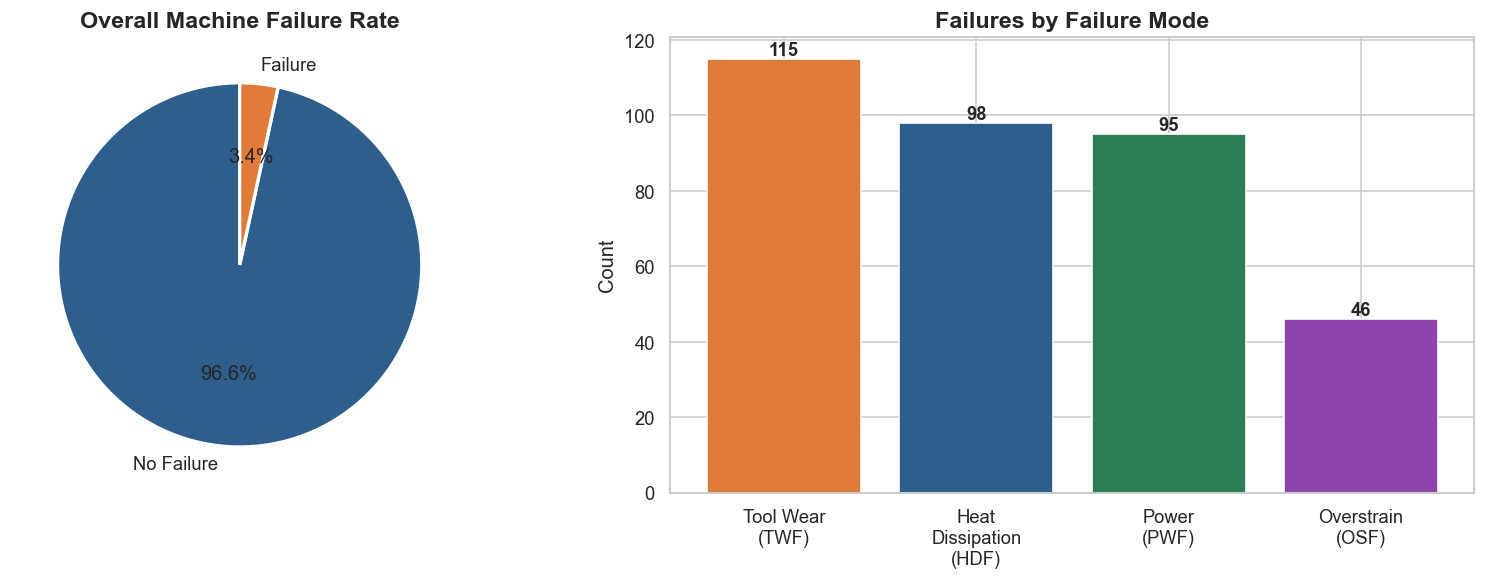


📌 FINDING: overall failure rate is 3.4%. and Tool Wear(TWF) is the most common cause of failure followed by Heat Dissipation(HDF)


In [7]:
# ── CELL 7: Failure Distribution ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 7a. Overall pass/fail
counts = df_clean['machine_failure'].value_counts()
axes[0].pie(
    counts, labels=['No Failure', 'Failure'],
    colors=['#2E5E8C', '#E07B39'],
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Overall Machine Failure Rate', fontsize=14, fontweight='bold')

# 7b. Breakdown by failure type
failure_types = df_clean[['twf', 'hdf', 'pwf', 'osf']].sum().sort_values(ascending=False)
colors = ['#E07B39', '#2E5E8C', '#2D7D52', '#8E44AD']
axes[1].bar(
    ['Tool Wear\n(TWF)', 'Heat\nDissipation\n(HDF)',
     'Power\n(PWF)', 'Overstrain\n(OSF)'],
    failure_types.values, color=colors, edgecolor='white'
)
axes[1].set_title('Failures by Failure Mode', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count')
for bar, val in zip(axes[1].patches, failure_types.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
               bar.get_height() + 1, str(val),
               ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../figures/01_failure_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📌 FINDING: overall failure rate is 3.4%. and Tool Wear(TWF) is the most common cause of failure followed by Heat Dissipation(HDF)")

In [8]:
# ── CELL 8: Failure Rate by Product Grade ───────────
grade_failure = df_clean.groupby('type')['machine_failure'].agg(
    ['mean', 'count', 'sum']
).reset_index()
grade_failure['failure_pct'] = grade_failure['mean'] * 100
grade_failure['type_label'] = grade_failure['type'].map({
    'L': 'Low Quality (L)', 'M': 'Medium Quality (M)', 'H': 'High Quality (H)'
})

fig = px.bar(
    grade_failure, x='type_label', y='failure_pct',
    text=grade_failure['failure_pct'].round(1).astype(str) + '%',
    color='failure_pct', color_continuous_scale='OrRd',
    title='Failure Rate by Product Quality Grade',
    labels={'failure_pct': 'Failure Rate (%)', 'type_label': 'Product Grade'}
)
fig.update_traces(textposition='outside')
fig.write_html('../figures/02_failure_by_grade.html')
fig.write_image('../figures/02_failure_by_grade.png', scale=2)
fig.show()

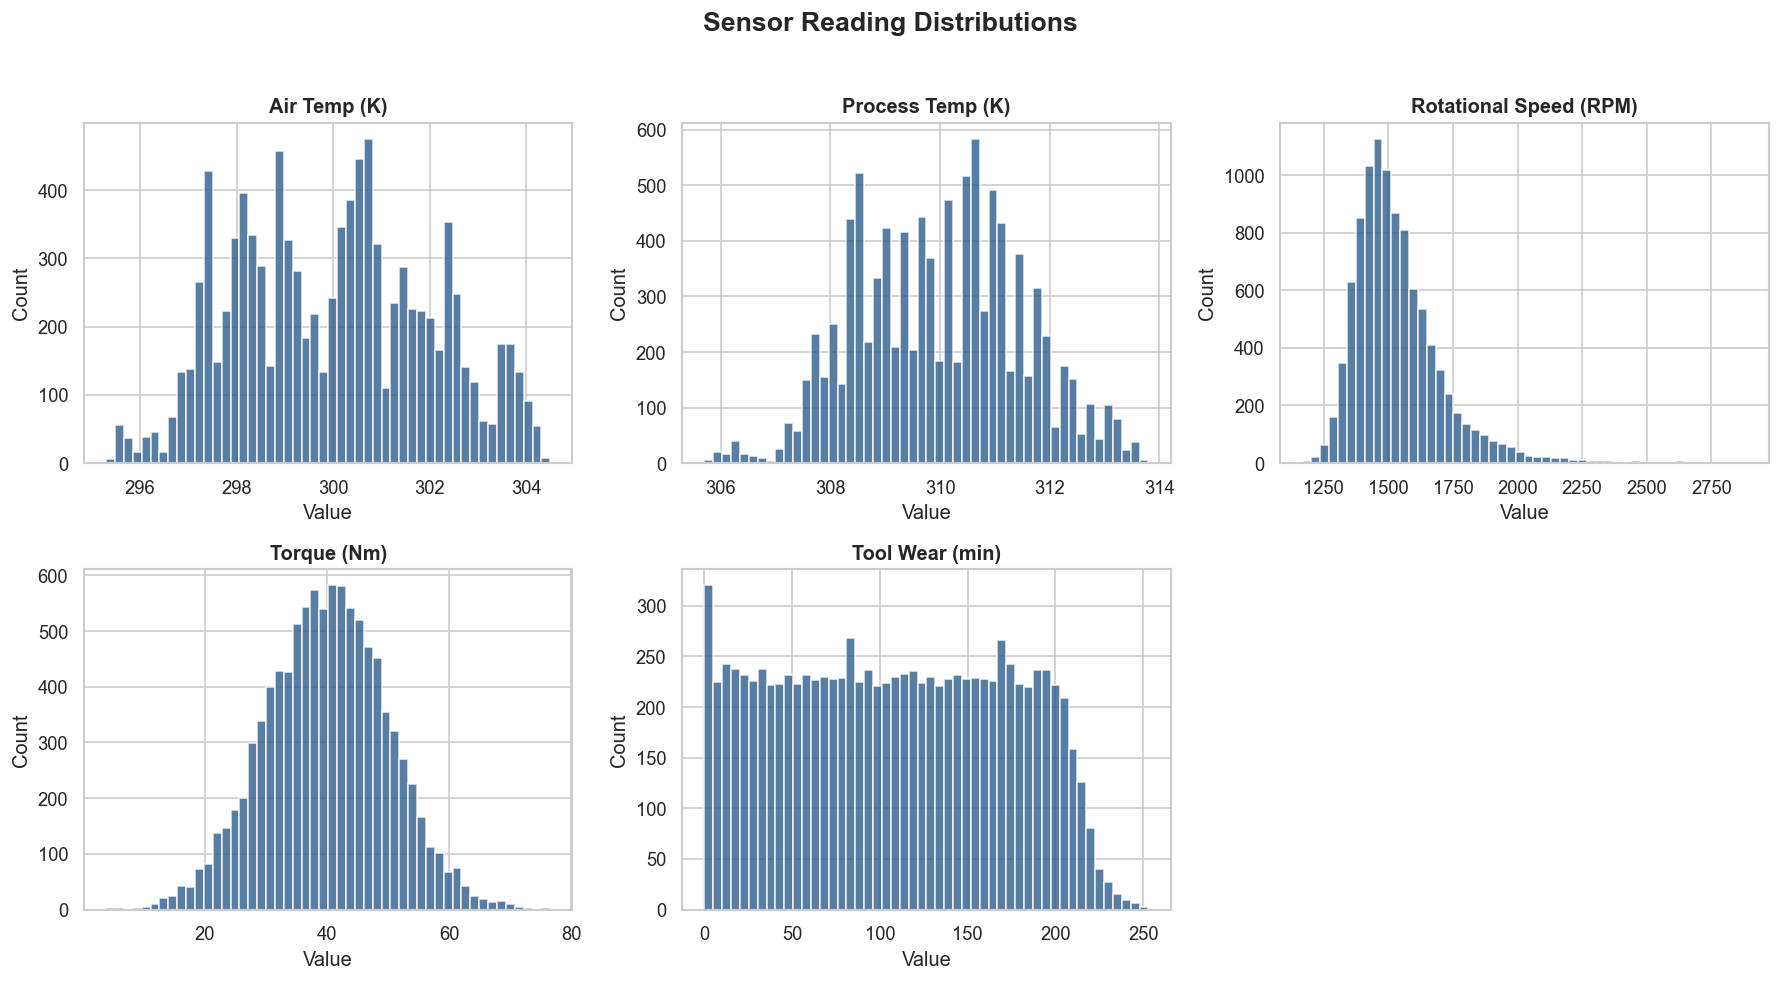

In [10]:
# ── CELL 9: Sensor Distributions ────────────────────
numeric_features = ['air_temp_k', 'process_temp_k', 'rpm', 'torque_nm', 'tool_wear_min']
feature_labels = ['Air Temp (K)', 'Process Temp (K)', 'Rotational Speed (RPM)',
                  'Torque (Nm)', 'Tool Wear (min)']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, (col, label) in enumerate(zip(numeric_features, feature_labels)):
    axes[i].hist(df_clean[col], bins=50, color='#2E5E8C', alpha=0.8, edgecolor='white')
    axes[i].set_title(label, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

axes[5].set_visible(False)  # hide empty 6th subplot
plt.suptitle('Sensor Reading Distributions', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figures/03_sensor_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

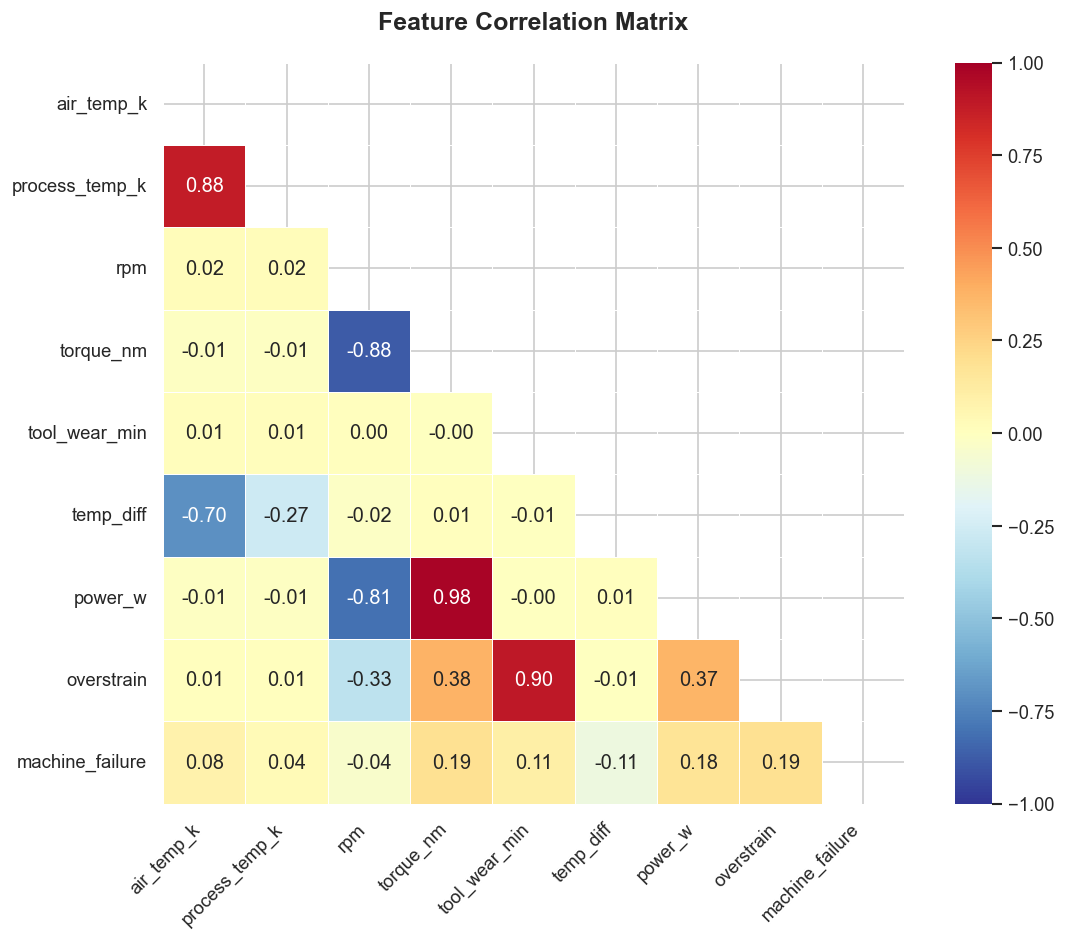

In [11]:
# ── CELL 10: Correlation Heatmap ────────────────────
corr_cols = ['air_temp_k', 'process_temp_k', 'rpm', 'torque_nm',
             'tool_wear_min', 'temp_diff', 'power_w', 'overstrain', 'machine_failure']

corr = df_clean[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))  # show only lower triangle
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, square=True,
    xticklabels=corr_cols, yticklabels=corr_cols, ax=ax
)
ax.set_title('Feature Correlation Matrix', fontsize=15, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../figures/04_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── CELL 11: Failure Rate vs Tool Wear ──────────────
wear_analysis = df_clean.groupby('wear_bin', observed=True)['machine_failure'].agg(
    failure_rate='mean', count='count'
).reset_index()
wear_analysis['failure_pct'] = wear_analysis['failure_rate'] * 100

fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(
    go.Bar(x=wear_analysis['wear_bin'].astype(str),
           y=wear_analysis['count'],
           name='Sample Count', marker_color='#B0C4DE', opacity=0.6),
    secondary_y=True
)
fig.add_trace(
    go.Scatter(x=wear_analysis['wear_bin'].astype(str),
               y=wear_analysis['failure_pct'],
               mode='lines+markers+text', name='Failure Rate (%)',
               line=dict(color='#E07B39', width=3),
               marker=dict(size=10, color='#E07B39'),
               text=wear_analysis['failure_pct'].round(1).astype(str) + '%',
               textposition='top center'),
    secondary_y=False
)

fig.update_layout(
    title='Failure Rate Escalates with Tool Wear Stage',
    title_font_size=16,
    xaxis_title='Tool Wear Stage',
    legend=dict(orientation='h', y=1.1),
    plot_bgcolor='white'
)
fig.update_yaxes(title_text='Failure Rate (%)', secondary_y=False)
fig.update_yaxes(title_text='Sample Count', secondary_y=True)

fig.write_html('../figures/05_failure_vs_wear.html')
fig.write_image('../figures/05_failure_vs_wear.png', scale=2)
fig.show()63.
+6
63+


In [13]:
# ── CELL 12: Power Distribution by Failure Status ───
df_plot = df_clean.copy()
df_plot['Status'] = df_plot['machine_failure'].map({0: 'No Failure', 1: 'Failure'})

fig = px.box(
    df_plot, x='Status', y='power_w',
    color='Status',
    color_discrete_map={'No Failure': '#2E5E8C', 'Failure': '#E07B39'},
    title='Mechanical Power: Failure vs. Normal Operation',
    labels={'power_w': 'Mechanical Power (W)', 'Status': 'Machine Status'},
    points='outliers'
)
fig.write_html('../figures/06_power_vs_failure.html')
fig.write_image('../figures/06_power_vs_failure.png', scale=2)
fig.show()

In [14]:
# ── CELL 13: Operating Envelope Scatter ─────────────
# Sample 3000 points for speed (scatter of 10k is slow)
df_sample = df_clean.sample(3000, random_state=42)
df_sample['Status'] = df_sample['machine_failure'].map({0: 'Normal', 1: 'Failed'})

fig = px.scatter(
    df_sample, x='rpm', y='torque_nm',
    color='Status',
    color_discrete_map={'Normal': '#2E5E8C', 'Failed': '#E07B39'},
    opacity=0.5, size_max=6,
    title='Operating Envelope: RPM vs Torque (colored by failure)',
    labels={'rpm': 'Rotational Speed (RPM)', 'torque_nm': 'Torque (Nm)'}
)
fig.write_html('../figures/07_operating_envelope.html')
fig.write_image('../figures/07_operating_envelope.png', scale=2)
fig.show()

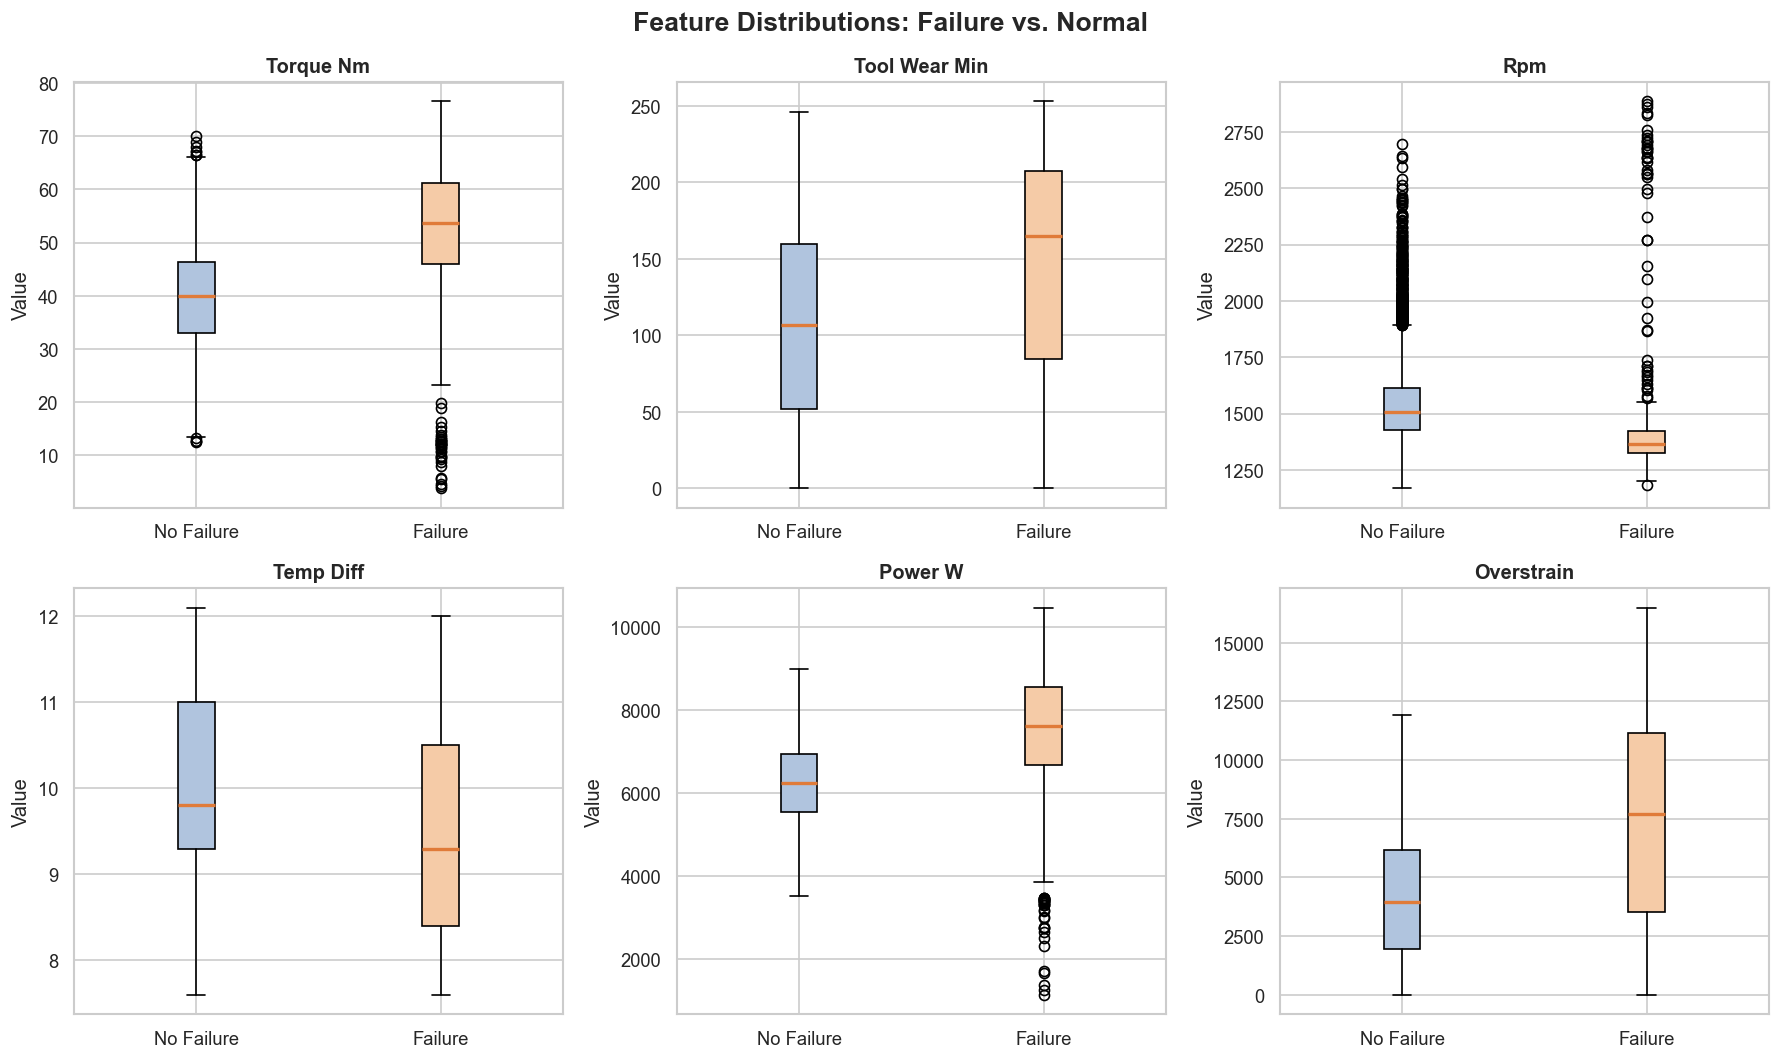

In [15]:
# ── CELL 14: Feature Separation by Failure ──────────
features_to_plot = ['torque_nm', 'tool_wear_min', 'rpm', 'temp_diff', 'power_w', 'overstrain']
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, col in enumerate(features_to_plot):
    fail = df_clean[df_clean['machine_failure'] == 1][col]
    nofail = df_clean[df_clean['machine_failure'] == 0][col]
    bp = axes[i].boxplot(
        [nofail, fail], labels=['No Failure', 'Failure'],
        patch_artist=True,
        boxprops=dict(facecolor='#B0C4DE'),
        medianprops=dict(color='#E07B39', linewidth=2)
    )
    bp['boxes'][1].set_facecolor('#F5CBA7')
    axes[i].set_title(col.replace('_', ' ').title(), fontweight='bold')
    axes[i].set_ylabel('Value')

plt.suptitle('Feature Distributions: Failure vs. Normal', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/08_feature_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()


In [16]:
# ── CELL 15: KPI Computation ────────────────────────

# KPI 1: Overall failure rate
failure_rate = df_clean['machine_failure'].mean() * 100
total_failures = df_clean['machine_failure'].sum()

# KPI 2: MTBF proxy (mean cycles between failures)
failure_indices = df_clean[df_clean['machine_failure'] == 1].index.tolist()
if len(failure_indices) > 1:
    mtbf = np.mean(np.diff(failure_indices))
else:
    mtbf = None

# KPI 3: Dominant failure mode (% of all failures)
failure_type_counts = df_clean[['twf', 'hdf', 'pwf', 'osf']].sum()
dominant_mode = failure_type_counts.idxmax()
dominant_pct = failure_type_counts.max() / total_failures * 100

# KPI 4: Failure rate in 'Critical' wear zone
critical_wear_rate = df_clean[df_clean['wear_bin'] == 'Critical']['machine_failure'].mean() * 100

# KPI 5: Low vs. High quality grade failure ratio
low_rate = df_clean[df_clean['type'] == 'L']['machine_failure'].mean() * 100
high_rate = df_clean[df_clean['type'] == 'H']['machine_failure'].mean() * 100

# Print all KPIs — WRITE THESE DOWN
print("=" * 50)
print("MANUFACTURING PROCESS ANALYTICS — KPI SUMMARY")
print("=" * 50)
print(f"KPI 1 — Overall Failure Rate:      {failure_rate:.2f}%")
print(f"KPI 2 — MTBF Proxy:                {mtbf:.0f} cycles")
print(f"KPI 3 — Dominant Failure Mode:     {dominant_mode.upper()} ({dominant_pct:.1f}% of failures)")
print(f"KPI 4 — Critical Wear Failure Rate:{critical_wear_rate:.1f}%")
print(f"KPI 5 — Low Grade Failure Rate:    {low_rate:.2f}%")
print(f"         High Grade Failure Rate:   {high_rate:.2f}%")

MANUFACTURING PROCESS ANALYTICS — KPI SUMMARY
KPI 1 — Overall Failure Rate:      3.39%
KPI 2 — MTBF Proxy:                29 cycles
KPI 3 — Dominant Failure Mode:     HDF (33.9% of failures)
KPI 4 — Critical Wear Failure Rate:15.5%
KPI 5 — Low Grade Failure Rate:    3.92%
         High Grade Failure Rate:   2.09%


In [17]:
# ── CELL 16: Statistical Driver Analysis ────────────
from scipy import stats

numerical_cols = ['air_temp_k', 'process_temp_k', 'rpm', 'torque_nm',
                  'tool_wear_min', 'temp_diff', 'power_w', 'overstrain']

failed = df_clean[df_clean['machine_failure'] == 1]
normal = df_clean[df_clean['machine_failure'] == 0]

results = []
for col in numerical_cols:
    t_stat, p_val = stats.ttest_ind(failed[col], normal[col])
    mean_diff_pct = (failed[col].mean() - normal[col].mean()) / normal[col].mean() * 100
    results.append({
        'Feature': col,
        'Mean (Normal)': round(normal[col].mean(), 2),
        'Mean (Failed)': round(failed[col].mean(), 2),
        'Diff %': round(mean_diff_pct, 1),
        'p-value': round(p_val, 6),
        'Significant': '✓' if p_val < 0.05 else '✗'
    })

driver_df = pd.DataFrame(results).sort_values('Diff %', ascending=False, key=abs)
print("=== FAILURE DRIVER RANKING ===")
print(driver_df.to_string(index=False))

=== FAILURE DRIVER RANKING ===
       Feature  Mean (Normal)  Mean (Failed)  Diff %  p-value Significant
    overstrain        4213.84        7187.94    70.6 0.000000           ✓
 tool_wear_min         106.69         143.78    34.8 0.000000           ✓
     torque_nm          39.63          50.17    26.6 0.000000           ✓
       power_w        6244.55        7282.82    16.6 0.000000           ✓
     temp_diff          10.02           9.40    -6.2 0.000000           ✓
           rpm        1540.26        1496.49    -2.8 0.000010           ✓
    air_temp_k         299.97         300.89     0.3 0.000000           ✓
process_temp_k         310.00         310.29     0.1 0.000324           ✓


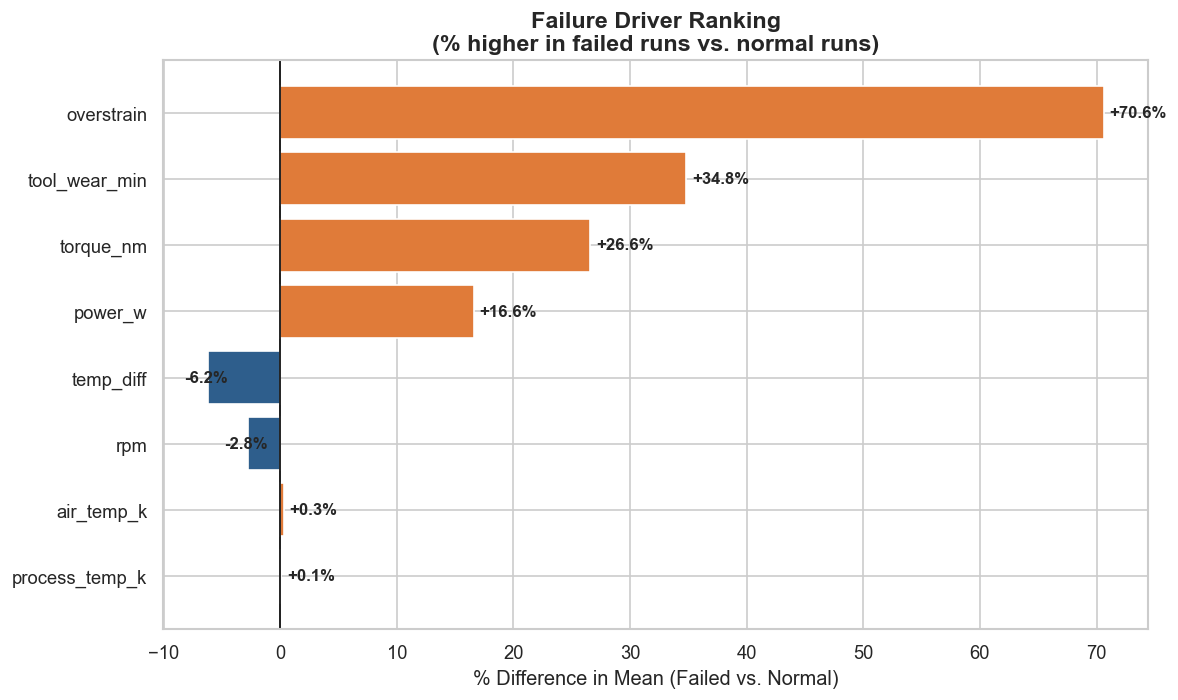


📌 KEY FINDING: Note the top 3 features by absolute Diff% — these are your 'drivers'


In [18]:
# ── CELL 17: Ranked Driver Bar Chart ────────────────
driver_sorted = driver_df.reindex(driver_df['Diff %'].abs().sort_values(ascending=True).index)
colors = ['#E07B39' if v > 0 else '#2E5E8C' for v in driver_sorted['Diff %']]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(driver_sorted['Feature'], driver_sorted['Diff %'], color=colors, edgecolor='white')
ax.axvline(x=0, color='black', linewidth=1)
ax.set_xlabel('% Difference in Mean (Failed vs. Normal)')
ax.set_title('Failure Driver Ranking\n(% higher in failed runs vs. normal runs)',
             fontsize=14, fontweight='bold')

for bar, val in zip(bars, driver_sorted['Diff %']):
    x = bar.get_width()
    ax.text(x + (0.5 if x >= 0 else -2), bar.get_y() + bar.get_height()/2,
            f'{val:+.1f}%', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../figures/09_driver_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📌 KEY FINDING: Note the top 3 features by absolute Diff% — these are your 'drivers'")


ROC-AUC: 0.9047

               precision    recall  f1-score   support

           0       0.99      0.95      0.97      1932
           1       0.34      0.79      0.48        68

    accuracy                           0.94      2000
   macro avg       0.67      0.87      0.72      2000
weighted avg       0.97      0.94      0.95      2000

DECISION TREE RULES:
|--- rpm <= 1386.50
|   |--- temp_diff <= 8.65
|   |   |--- process_temp_k <= 312.05
|   |   |   |--- class: 1
|   |   |--- process_temp_k >  312.05
|   |   |   |--- class: 0
|   |--- temp_diff >  8.65
|   |   |--- overstrain <= 11013.60
|   |   |   |--- class: 0
|   |   |--- overstrain >  11013.60
|   |   |   |--- class: 1
|--- rpm >  1386.50
|   |--- tool_wear_min <= 204.50
|   |   |--- power_w <= 3496.14
|   |   |   |--- class: 1
|   |   |--- power_w >  3496.14
|   |   |   |--- class: 0
|   |--- tool_wear_min >  204.50
|   |   |--- overstrain <= 10972.10
|   |   |   |--- class: 1
|   |   |--- overstrain >  10972.10
|   |   

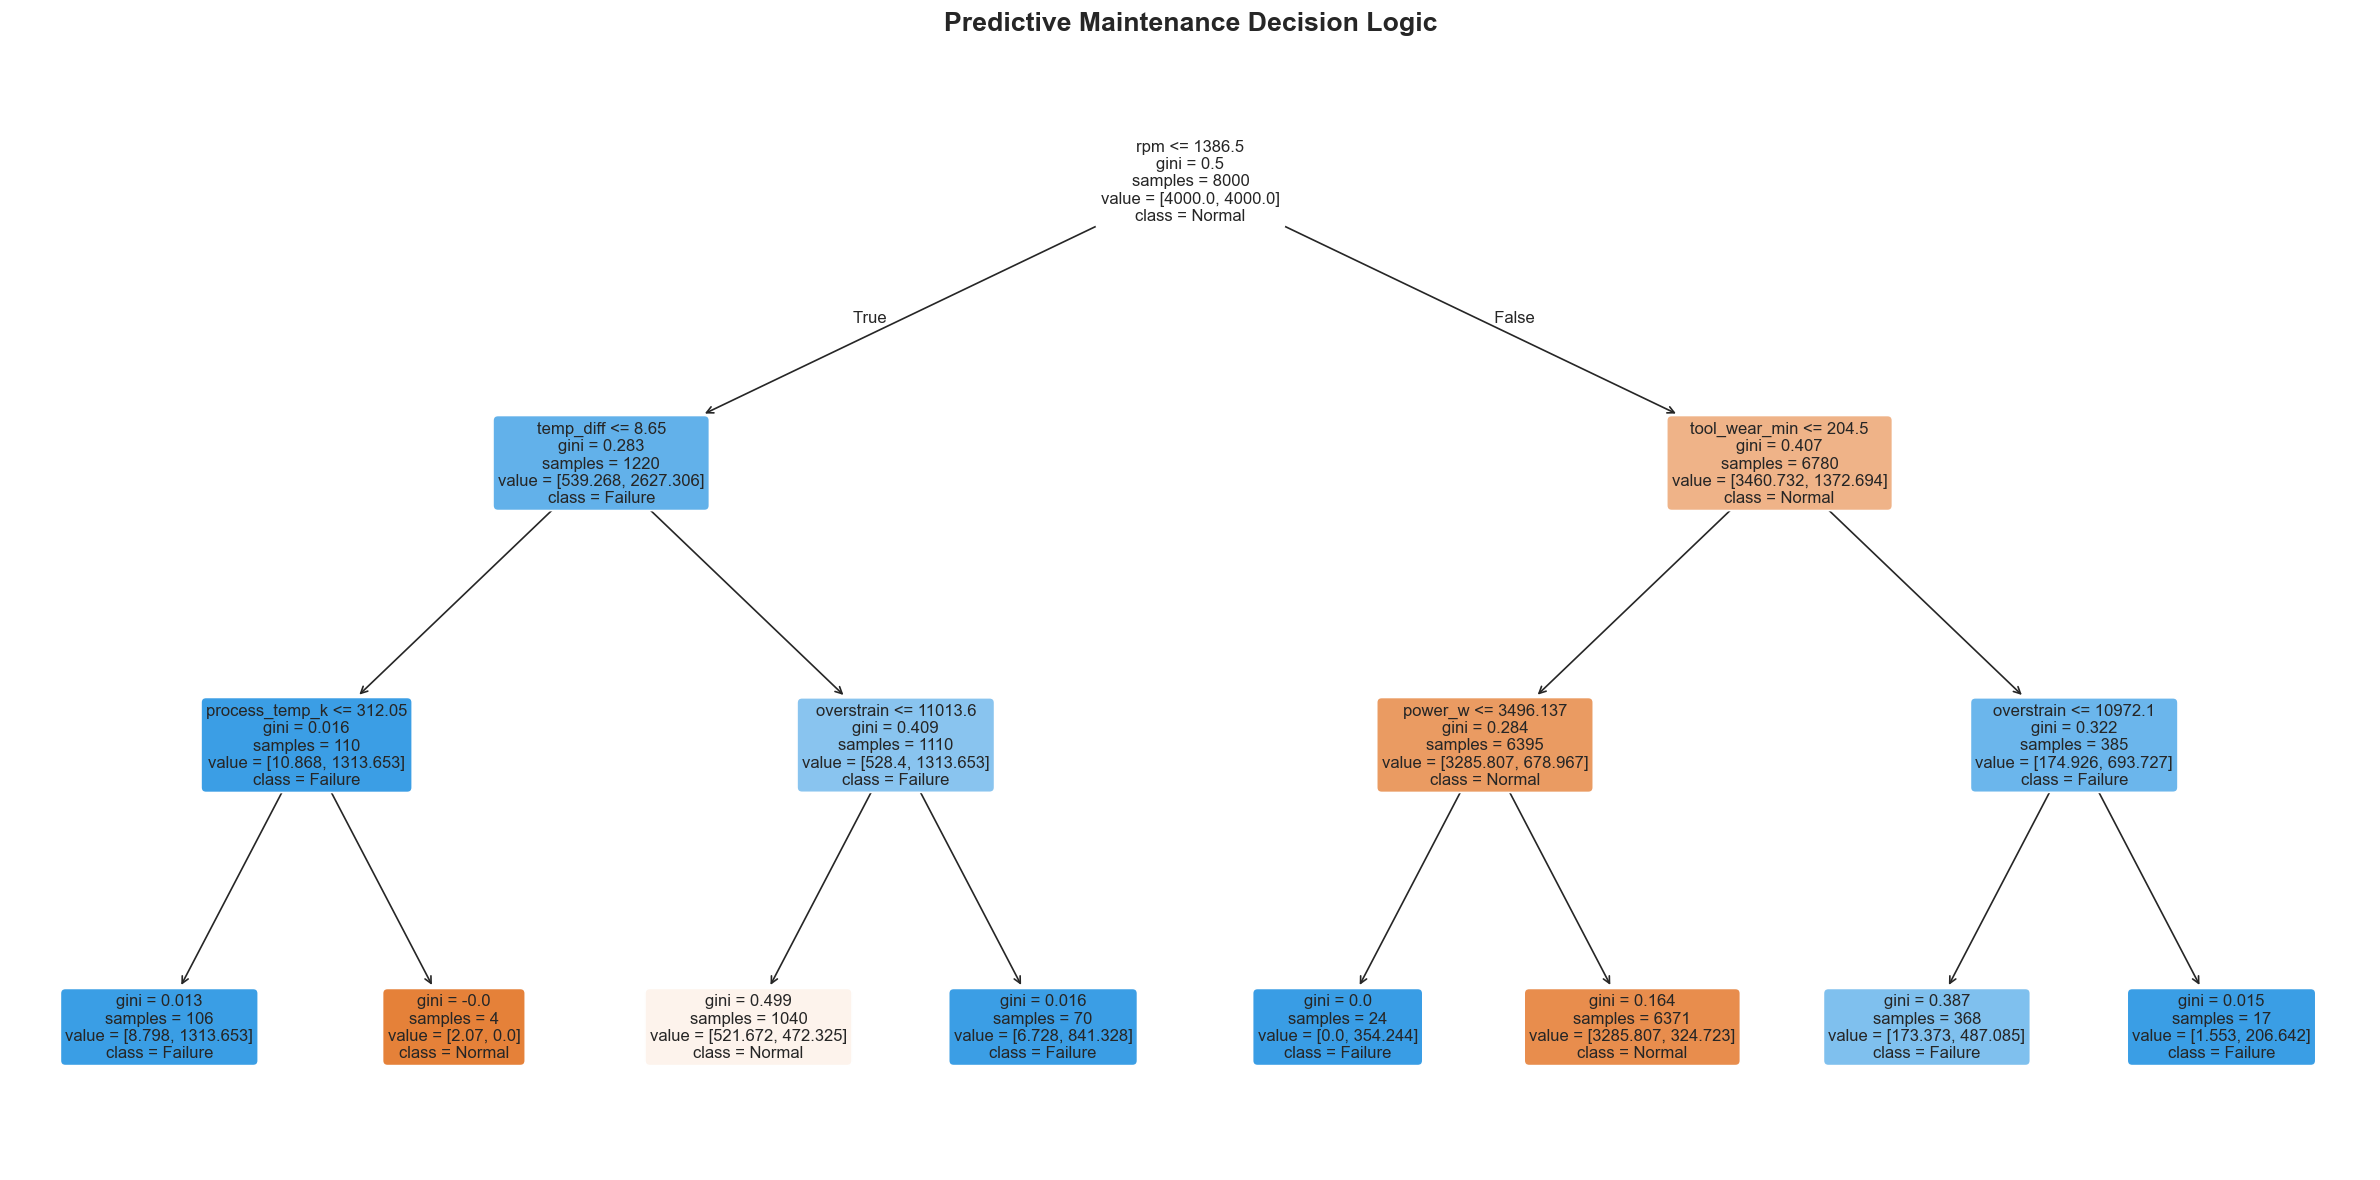

In [21]:
# ── CELL 18: Decision Tree ──────────────────────────
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler
import joblib

feature_cols = ['air_temp_k', 'process_temp_k', 'rpm', 'torque_nm',
                'tool_wear_min', 'type_encoded', 'temp_diff', 'power_w', 'overstrain']

X = df_clean[feature_cols]
y = df_clean['machine_failure']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Depth-3 tree: interpretable, not overfit
dt = DecisionTreeClassifier(max_depth=3, class_weight='balanced', random_state=42)
dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)
y_prob = dt.predict_proba(X_test)[:, 1]

print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")
print("\n", classification_report(y_test, y_pred))

# Print the text version of the decision tree
tree_rules = export_text(dt, feature_names=feature_cols)
print("DECISION TREE RULES:")
print(tree_rules)


import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Create a massive canvas so the text is readable
plt.figure(figsize=(20, 10))

# Plot the tree
plot_tree(dt, 
          feature_names=feature_cols, 
          class_names=['Normal', 'Failure'], 
          filled=True, 
          rounded=True, 
          fontsize=10)

plt.title("Predictive Maintenance Decision Logic", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

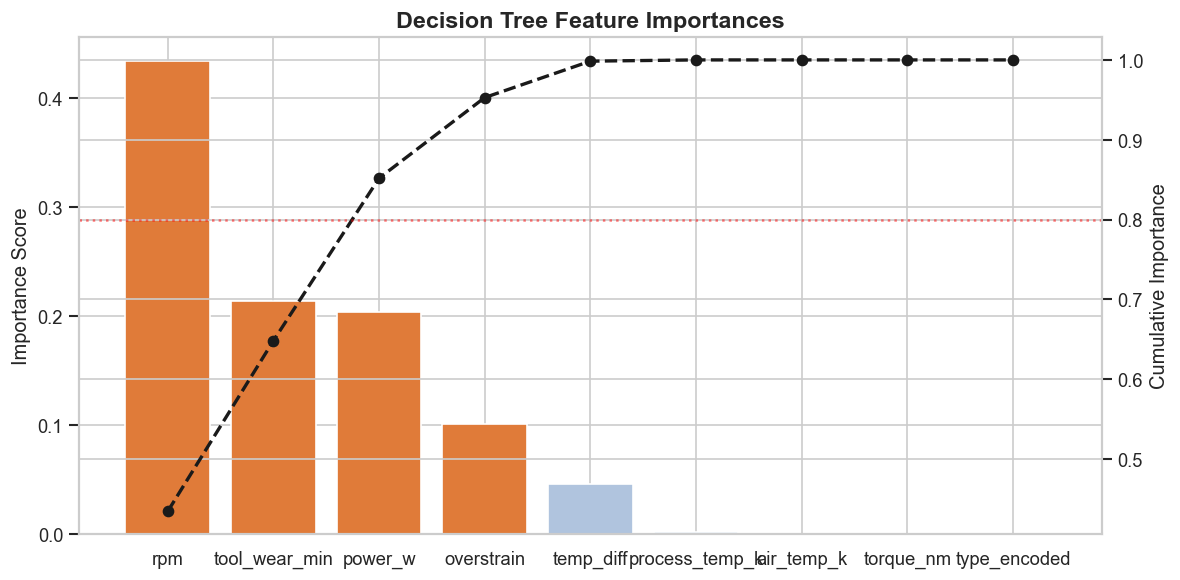


Top 3 features account for 80%+ of model decisions
rpm              0.434312
tool_wear_min    0.213797
power_w          0.203674
dtype: float64


In [22]:
# ── CELL 19: Feature Importances ────────────────────
importances = pd.Series(dt.feature_importances_, index=feature_cols).sort_values(ascending=False)
cumulative = importances.cumsum()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(importances.index, importances.values,
              color=['#E07B39' if v > 0.05 else '#B0C4DE' for v in importances.values],
              edgecolor='white')
ax2 = ax.twinx()
ax2.plot(importances.index, cumulative.values, 'k--', marker='o', linewidth=2, label='Cumulative')
ax2.axhline(y=0.8, color='red', linestyle=':', alpha=0.5)
ax2.set_ylabel('Cumulative Importance')
ax.set_title('Decision Tree Feature Importances', fontsize=14, fontweight='bold')
ax.set_ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../figures/10_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Identify how many features to reach 80% cumulative importance
n_to_80 = (cumulative < 0.8).sum() + 1
print(f"\nTop {n_to_80} features account for 80%+ of model decisions")
print(importances.head(n_to_80))

In [23]:
# ── CELL 20: Save Outputs ───────────────────────────
joblib.dump(dt, '../outputs/decision_tree_model.pkl')
importances.to_csv('../outputs/feature_importances.csv')
driver_df.to_csv('../outputs/driver_analysis.csv', index=False)
print("✓ Model and outputs saved")


✓ Model and outputs saved
